# Réseaux Neuronaux (MLP) pour la Sécurisation Decision-LWE
### Mini Projet - Module Cryptographie | ENSA Béni Mellal
### Binôme  : Machhouri Abderrahman & Zouhiri Hasnae
### Prof : OUNACHAD | S2 - 2025/26

---

## Problématique

Le problème **Decision-LWE** (Learning With Errors) consiste à distinguer entre :
- Des paires **(a, b = a·s + e mod q)** → échantillons LWE valides (label = 1)
- Des paires **(a, u)** où u est uniforme aléatoire (label = 0)

Ce problème est au cœur de la **cryptographie post-quantique** (utilisé dans CRYSTALS-Kyber, sélectionné par le NIST).


## Structure du Notebook

1. Installation et Imports
2. Fonctions utilitaires
3. **Expérience 1** : n=8, q=97 
4. **Expérience 2** : n=16, q=257 
5. **Expérience 3** : n=32, q=521 
6. **Expérience 4** : n=64, q=1031
7. Comparaison globale et analyse
8. Conclusion


## 1. Installation et Imports

In [1]:
# Installation des dépendances (décommenter si nécessaire)
# !pip install torch pandas numpy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device utilisé  : {device}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU détecté → entraînement sur CPU")


PyTorch version : 2.11.0+cpu
Device utilisé  : cpu
Pas de GPU détecté → entraînement sur CPU


## 2. Fonctions Utilitaires

In [2]:
# Chemin vers les datasets
DATASET_DIR = "datasets/"


In [3]:
def preprocess_data(df, q, batch_size=64):
    X = df.drop('label', axis=1).values.astype(np.float32)
    y = df['label'].values.astype(np.float32)
    X = X / q

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"  Train : {train_size} | Validation : {val_size} | Test : {len(test_dataset)}")
    return train_loader, val_loader, test_loader, X_test, y_test


In [4]:
class DecisionLWE_MLP(nn.Module):
    """
    MLP adapté au problème Decision-LWE.
    Le MLP connecte TOUTES les entrées à chaque neurone,
    ce qui lui permet d'apprendre la combinaison linéaire a·s.
    """
    def __init__(self, input_size):
        super(DecisionLWE_MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model_demo = DecisionLWE_MLP(input_size=9).to(device)
print(model_demo)
total_params = sum(p.numel() for p in model_demo.parameters())
print(f"\nNombre total de paramètres : {total_params:,}")


DecisionLWE_MLP(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
    (15): Sigmoid()
  )
)

Nombre total de paramètres : 46,721


In [5]:
def train_model(df, n, q, epochs=100, patience=15):
    train_loader, val_loader, test_loader, X_test_np, y_test_np = preprocess_data(df, q)
    input_size = df.shape[1] - 1
    model = DecisionLWE_MLP(input_size).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
    )

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            train_correct += (preds == y_batch).sum().item()
            train_total += y_batch.size(0)
        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                preds = (outputs >= 0.5).float()
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  ⏹ Early stopping à l'epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    all_preds, all_proba = [], []
    test_loss, test_correct, test_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            test_correct += (preds == y_batch).sum().item()
            test_total += y_batch.size(0)
            all_proba.extend(outputs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())

    test_loss /= test_total
    test_acc = test_correct / test_total
    y_pred = np.array(all_preds).astype(int)
    y_pred_proba = np.array(all_proba)

    print(f"\n  📊 Résultats sur le test set :")
    print(f"     Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"     Loss     : {test_loss:.4f}")

    return {
        "model": model, "history": history,
        "test_acc": test_acc, "test_loss": test_loss,
        "y_test": y_test_np, "y_pred": y_pred, "y_pred_proba": y_pred_proba,
        "X_test": X_test_np
    }


In [6]:
def plot_training_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['accuracy'], label='Train', linewidth=2, color='steelblue')
    ax1.plot(history['val_accuracy'], label='Validation', linewidth=2, color='coral')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Hasard (50%)')
    ax1.set_title(f'Accuracy - {title}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.set_ylim([0.4, 1.05]); ax1.grid(True, alpha=0.3)
    ax2.plot(history['loss'], label='Train', linewidth=2, color='steelblue')
    ax2.plot(history['val_loss'], label='Validation', linewidth=2, color='coral')
    ax2.set_title(f'Loss - {title}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(y_test, y_pred, test_acc, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Aléatoire (0)', 'LWE (1)'],
                yticklabels=['Aléatoire (0)', 'LWE (1)'])
    plt.title(f'Matrice de Confusion - {title}\nAccuracy = {test_acc:.2%}',
              fontsize=13, fontweight='bold')
    plt.ylabel('Classe réelle'); plt.xlabel('Classe prédite')
    plt.tight_layout(); plt.show()

def plot_roc_curve(y_test, y_pred_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC = 0.5)')
    plt.xlabel('Taux de Faux Positifs'); plt.ylabel('Taux de Vrais Positifs')
    plt.title(f'Courbe ROC - {title}', fontsize=13, fontweight='bold')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return roc_auc


In [7]:
def show_predictions(result, title, n, q, num_samples=15):
    """
    Affiche un tableau de prédictions concrètes.
    C'est ICI qu'on voit clairement si le modèle réussit ou échoue :
    
    - Probabilité proche de 1.0 → le modèle est SÛR que c'est LWE
    - Probabilité proche de 0.0 → le modèle est SÛR que c'est Aléatoire
    - Probabilité proche de 0.5 → le modèle HÉSITE (ne sait pas distinguer)
    """
    y_test = result['y_test']
    y_pred = result['y_pred']
    y_proba = result['y_pred_proba']

    print(f"\n{'='*75}")
    print(f"  PRÉDICTIONS DÉTAILLÉES : {title}")
    print(f"{'='*75}")
    print(f"  {'N°':>3} │ {'Vraie Classe':>14} │ {'Prédiction':>12} │ {'Probabilité':>12} │ {'Résultat':>10}")
    print(f"  {'─'*3}─┼─{'─'*14}─┼─{'─'*12}─┼─{'─'*12}─┼─{'─'*10}")

    idx_lwe = np.where(y_test == 1)[0][:num_samples//2 + 1]
    idx_rand = np.where(y_test == 0)[0][:num_samples//2 + 1]
    indices = np.concatenate([idx_lwe, idx_rand])[:num_samples]
    np.random.seed(42)
    np.random.shuffle(indices)

    correct = 0
    for i, idx in enumerate(indices):
        vrai = "LWE (1)" if y_test[idx] == 1 else "Aléatoire (0)"
        pred = "LWE (1)" if y_pred[idx] == 1 else "Aléatoire (0)"
        proba = y_proba[idx]
        ok = "✅" if y_test[idx] == y_pred[idx] else "❌"
        if y_test[idx] == y_pred[idx]:
            correct += 1
        print(f"  {i+1:3d} │ {vrai:>14} │ {pred:>12} │ {proba:>11.4f} │ {ok:>10}")

    print(f"  {'─'*3}─┴─{'─'*14}─┴─{'─'*12}─┴─{'─'*12}─┴─{'─'*10}")
    print(f"  Score sur ces {num_samples} exemples : {correct}/{num_samples} ({correct/num_samples*100:.0f}%)")

    proba_lwe = y_proba[y_test == 1]
    proba_rand = y_proba[y_test == 0]

    print(f"\n  📈 Distribution des probabilités :")
    print(f"     Vrais LWE      → Proba moyenne : {proba_lwe.mean():.4f} (idéal : 1.0)")
    print(f"     Vrais Aléatoire → Proba moyenne : {proba_rand.mean():.4f} (idéal : 0.0)")

    separation = abs(proba_lwe.mean() - proba_rand.mean())
    if separation > 0.3:
        print(f"     ✅ Bonne séparation ({separation:.4f}) → le modèle DISTINGUE les classes")
    elif separation > 0.1:
        print(f"     ⚠️  Séparation faible ({separation:.4f}) → le modèle a du mal")
    else:
        print(f"     ❌ Pas de séparation ({separation:.4f}) → le modèle NE DISTINGUE PAS")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(proba_lwe, bins=30, alpha=0.7, label='Vrais LWE (label=1)', color='steelblue')
    ax.hist(proba_rand, bins=30, alpha=0.7, label='Vrais Aléatoire (label=0)', color='coral')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Seuil (0.5)')
    ax.set_xlabel('Probabilité prédite', fontsize=12)
    ax.set_ylabel("Nombre d'échantillons", fontsize=12)
    ax.set_title(f'Distribution des Probabilités - {title}', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"\n  💡 INTERPRÉTATION :")
    if separation > 0.3:
        print(f"     Le modèle RÉUSSIT : les probabilités des LWE sont séparées des aléatoires")
        print(f"     → n={n} n'est PAS sûr pour la cryptographie.")
    else:
        print(f"     Le modèle ÉCHOUE : toutes les probabilités sont autour de 0.5")
        print(f"     → n={n} est SÛR pour la cryptographie.")


---
## 3. Expérience 1 : n=8, q=97 

**Paramètres :** n=8, q=97, σ=3.0

Avec une petite dimension, le MLP devrait **réussir** à distinguer LWE du bruit.


In [8]:
df_n8 = pd.read_csv(DATASET_DIR + "decision_lwe_n8_q97.csv")
print(f"Dataset n=8, q=97")
print(f"  Taille : {df_n8.shape[0]} échantillons, {df_n8.shape[1]-1} features")
print(f"  Labels : {dict(df_n8['label'].value_counts())}")
df_n8.head(10)


Dataset n=8, q=97
  Taille : 10000 échantillons, 9 features
  Labels : {0: np.int64(5000), 1: np.int64(5000)}


,a_0,a_1,a_2,a_3,a_4,a_5,a_6,a_7,b,label
0,8,7,8,16,23,71,13,53,79,0
1,92,8,36,59,55,88,11,70,83,1
2,88,31,7,68,29,7,18,58,49,1
3,87,7,53,93,0,19,33,56,61,1
4,96,83,63,27,3,33,3,69,41,1
5,47,90,52,60,86,10,14,89,10,0
6,69,46,86,67,90,17,20,91,12,1
7,60,65,93,85,52,64,26,6,64,0
8,43,15,10,9,50,41,84,24,5,0
9,23,23,3,66,33,56,48,86,39,1


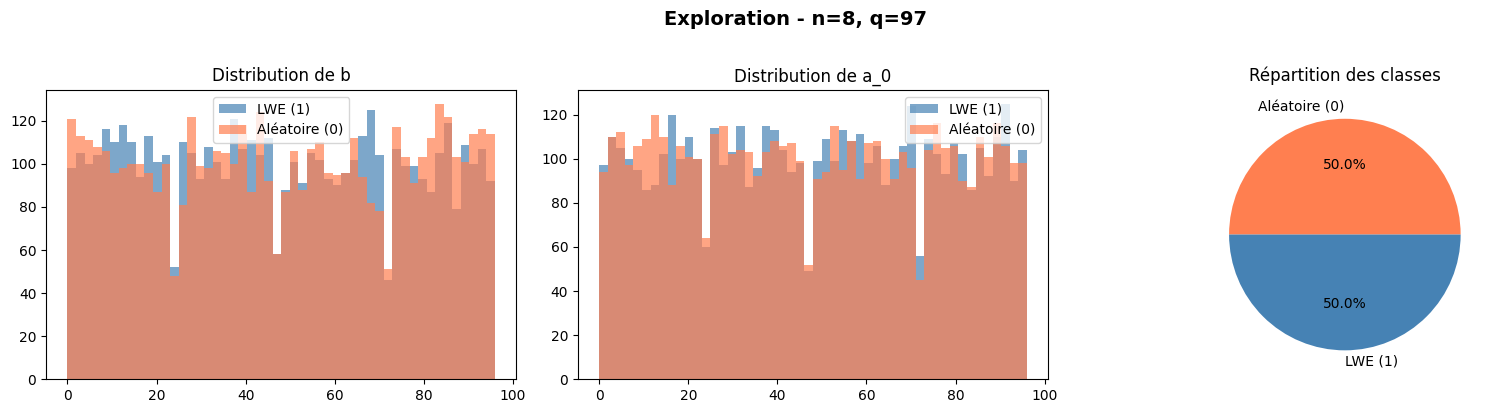

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df_n8[df_n8['label']==1]['b'], bins=50, alpha=0.7, label='LWE (1)', color='steelblue')
axes[0].hist(df_n8[df_n8['label']==0]['b'], bins=50, alpha=0.7, label='Aléatoire (0)', color='coral')
axes[0].set_title('Distribution de b'); axes[0].legend()
axes[1].hist(df_n8[df_n8['label']==1]['a_0'], bins=50, alpha=0.7, label='LWE (1)', color='steelblue')
axes[1].hist(df_n8[df_n8['label']==0]['a_0'], bins=50, alpha=0.7, label='Aléatoire (0)', color='coral')
axes[1].set_title('Distribution de a_0'); axes[1].legend()
axes[2].pie(df_n8['label'].value_counts(), labels=['Aléatoire (0)','LWE (1)'], autopct='%1.1f%%', colors=['coral','steelblue'])
axes[2].set_title('Répartition des classes')
plt.suptitle('Exploration - n=8, q=97', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [10]:
print("=" * 60)
print("  ENTRAÎNEMENT : n=8, q=97 (Difficulté Faible)")
print("=" * 60)
result_n8 = train_model(df_n8, n=8, q=97, epochs=100)
print(f"\n{'='*60}")
print(f"  RÉSULTAT FINAL : Accuracy = {result_n8['test_acc']:.2%}")
print(f"{'='*60}")
print(f"\n{classification_report(result_n8['y_test'], result_n8['y_pred'], target_names=['Aléatoire', 'LWE'])}")


  ENTRAÎNEMENT : n=8, q=97 (Difficulté Faible)
  Train : 6400 | Validation : 1600 | Test : 2000
  Epoch   1/100 | Train Loss: 0.6940 Acc: 0.5041 | Val Loss: 0.6956 Acc: 0.4844
  Epoch  10/100 | Train Loss: 0.6875 Acc: 0.5447 | Val Loss: 0.6978 Acc: 0.4863
  ⏹ Early stopping à l'epoch 16

  📊 Résultats sur le test set :
     Accuracy : 0.5140 (51.40%)
     Loss     : 0.6967

  RÉSULTAT FINAL : Accuracy = 51.40%

              precision    recall  f1-score   support

   Aléatoire       0.52      0.43      0.47      1000
         LWE       0.51      0.60      0.55      1000

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



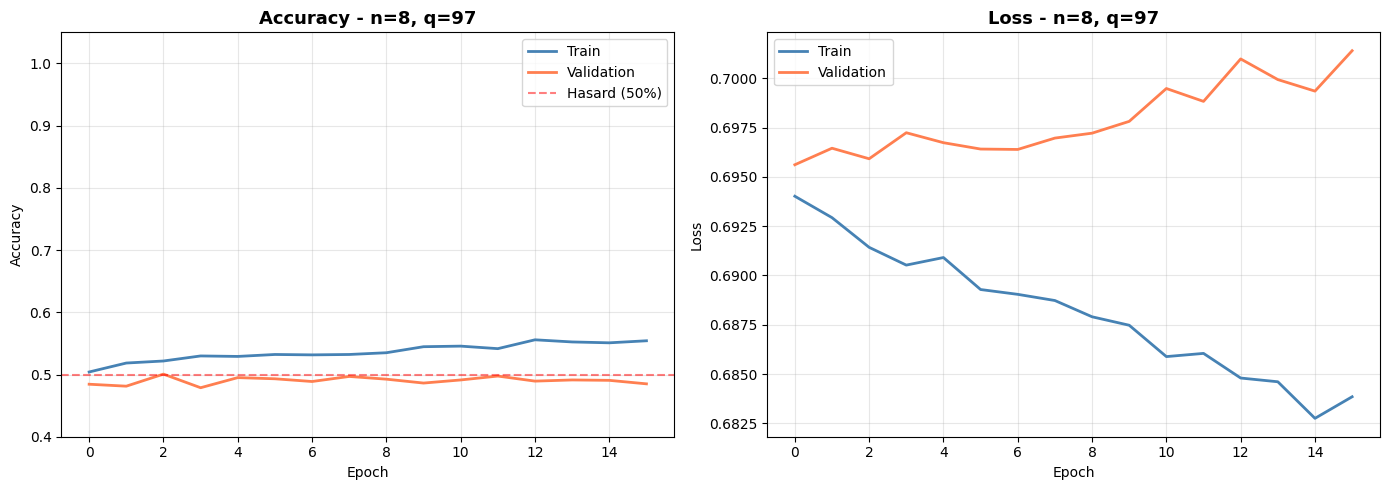

In [11]:
plot_training_curves(result_n8['history'], 'n=8, q=97')

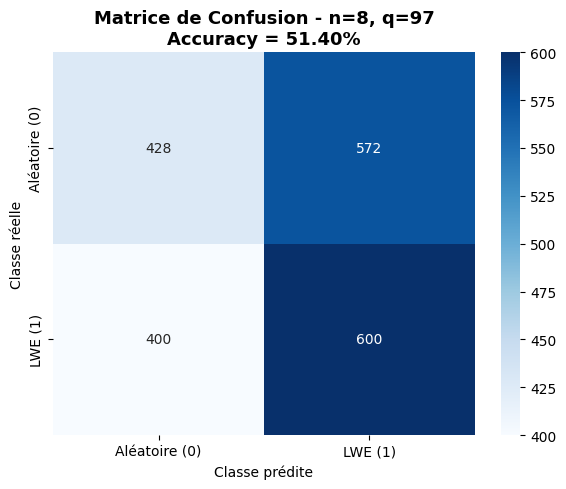

In [12]:
plot_confusion_matrix(result_n8['y_test'], result_n8['y_pred'], result_n8['test_acc'], 'n=8, q=97')

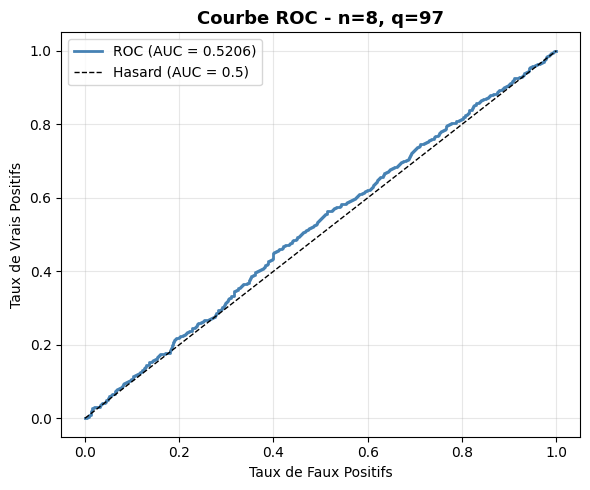

In [13]:
auc_n8 = plot_roc_curve(result_n8['y_test'], result_n8['y_pred_proba'], 'n=8, q=97')


  PRÉDICTIONS DÉTAILLÉES : n=8, q=97
   N° │   Vraie Classe │   Prédiction │  Probabilité │   Résultat
  ────┼────────────────┼──────────────┼──────────────┼───────────
    1 │  Aléatoire (0) │      LWE (1) │      0.5148 │          ❌
    2 │  Aléatoire (0) │ Aléatoire (0) │      0.4693 │          ✅
    3 │        LWE (1) │      LWE (1) │      0.5574 │          ✅
    4 │  Aléatoire (0) │      LWE (1) │      0.5250 │          ❌
    5 │        LWE (1) │      LWE (1) │      0.5488 │          ✅
    6 │  Aléatoire (0) │      LWE (1) │      0.5623 │          ❌
    7 │        LWE (1) │      LWE (1) │      0.5547 │          ✅
    8 │        LWE (1) │      LWE (1) │      0.5524 │          ✅
    9 │  Aléatoire (0) │ Aléatoire (0) │      0.4355 │          ✅
   10 │        LWE (1) │ Aléatoire (0) │      0.4138 │          ❌
   11 │        LWE (1) │ Aléatoire (0) │      0.4940 │          ❌
   12 │  Aléatoire (0) │      LWE (1) │      0.5964 │          ❌
   13 │  Aléatoire (0) │      LWE (1) │      0

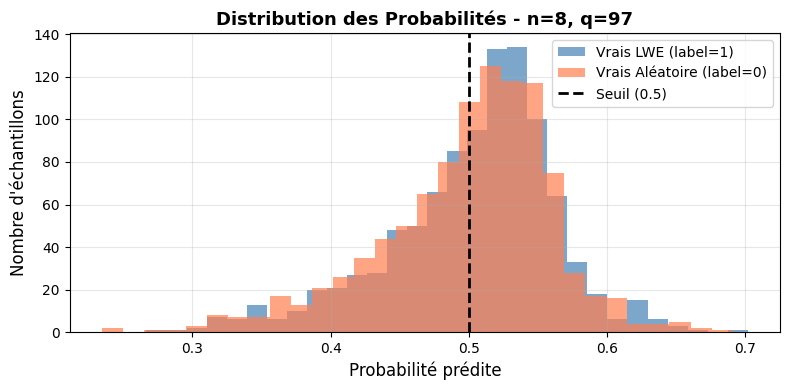


  💡 INTERPRÉTATION :
     Le modèle ÉCHOUE : toutes les probabilités sont autour de 0.5
     → n=8 est SÛR pour la cryptographie.


In [14]:
show_predictions(result_n8, 'n=8, q=97', n=8, q=97)

### Analyse - Expérience 1 (n=8)

**Comment lire les résultats :**
1. **Tableau de prédictions** : chaque ligne = un échantillon. ✅ = bonne prédiction, ❌ = erreur
2. **Histogramme** : si 2 bosses séparées → le modèle distingue bien. Si 1 bosse à 0.5 → il échoue
3. **Matrice de confusion** : gros nombres sur la diagonale = bon modèle

Avec n=8 le MLP devrait réussir → n=8 **n'est PAS sûr** pour la cryptographie.


---
## 4. Expérience 2 : n=16, q=257 

**Paramètres :** n=16, q=257, σ=4.0


In [15]:
df_n16 = pd.read_csv(DATASET_DIR + "decision_lwe_n16_q257.csv")
print(f"Dataset n=16, q=257 : {df_n16.shape[0]} échantillons, Labels : {dict(df_n16['label'].value_counts())}")


Dataset n=16, q=257 : 10000 échantillons, Labels : {0: np.int64(5000), 1: np.int64(5000)}


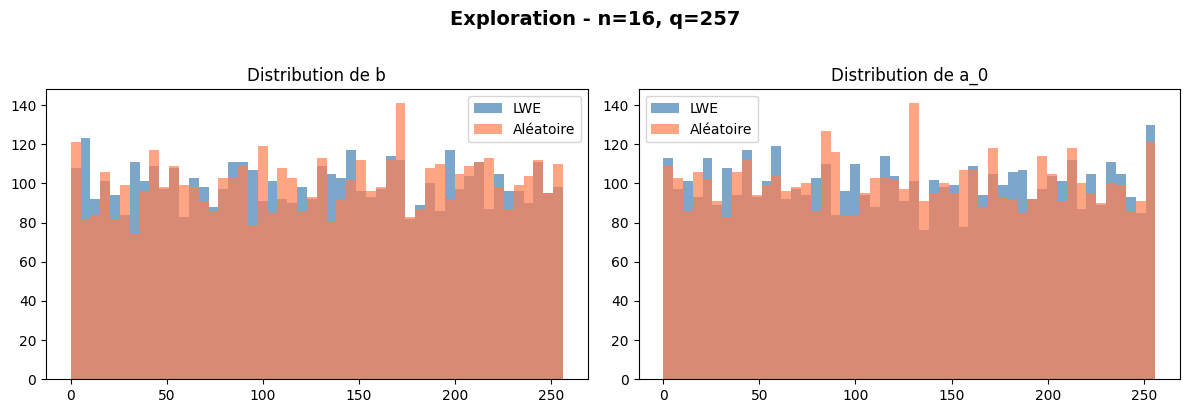

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_n16[df_n16['label']==1]['b'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[0].hist(df_n16[df_n16['label']==0]['b'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[0].set_title('Distribution de b'); axes[0].legend()
axes[1].hist(df_n16[df_n16['label']==1]['a_0'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[1].hist(df_n16[df_n16['label']==0]['a_0'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[1].set_title('Distribution de a_0'); axes[1].legend()
plt.suptitle('Exploration - n=16, q=257', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [17]:
print("=" * 60)
print("  ENTRAÎNEMENT : n=16, q=257 (Difficulté Moyenne)")
print("=" * 60)
result_n16 = train_model(df_n16, n=16, q=257, epochs=100)
print(f"\n  RÉSULTAT FINAL : Accuracy = {result_n16['test_acc']:.2%}")
print(f"\n{classification_report(result_n16['y_test'], result_n16['y_pred'], target_names=['Aléatoire', 'LWE'])}")


  ENTRAÎNEMENT : n=16, q=257 (Difficulté Moyenne)
  Train : 6400 | Validation : 1600 | Test : 2000
  Epoch   1/100 | Train Loss: 0.6959 Acc: 0.5047 | Val Loss: 0.6942 Acc: 0.5000
  Epoch  10/100 | Train Loss: 0.6777 Acc: 0.5647 | Val Loss: 0.7023 Acc: 0.5106
  ⏹ Early stopping à l'epoch 16

  📊 Résultats sur le test set :
     Accuracy : 0.5015 (50.15%)
     Loss     : 0.7115

  RÉSULTAT FINAL : Accuracy = 50.15%

              precision    recall  f1-score   support

   Aléatoire       0.50      0.44      0.47      1000
         LWE       0.50      0.57      0.53      1000

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



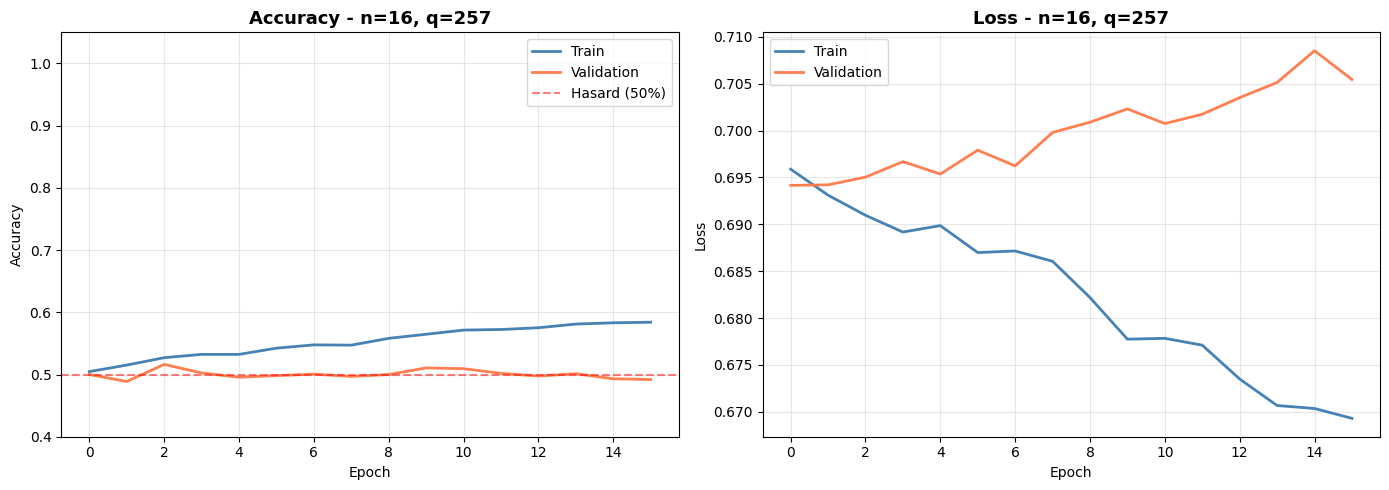

In [18]:
plot_training_curves(result_n16['history'], 'n=16, q=257')

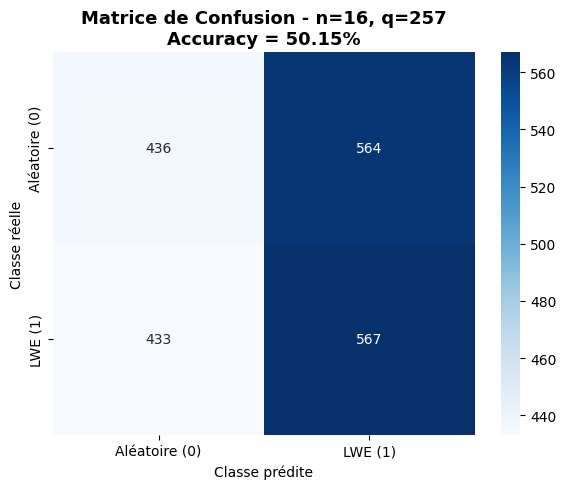

In [19]:
plot_confusion_matrix(result_n16['y_test'], result_n16['y_pred'], result_n16['test_acc'], 'n=16, q=257')

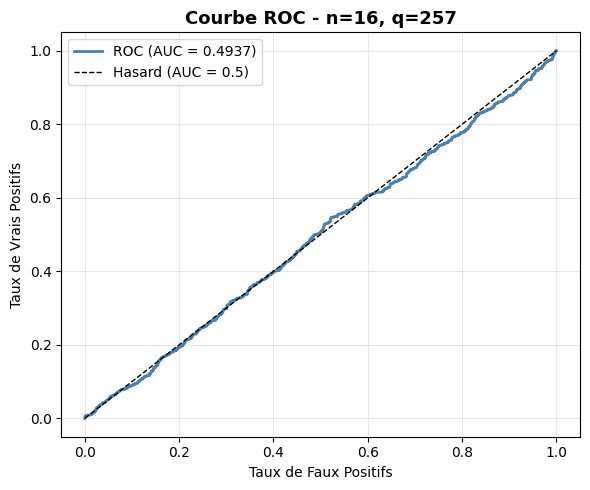

In [20]:
auc_n16 = plot_roc_curve(result_n16['y_test'], result_n16['y_pred_proba'], 'n=16, q=257')


  PRÉDICTIONS DÉTAILLÉES : n=16, q=257
   N° │   Vraie Classe │   Prédiction │  Probabilité │   Résultat
  ────┼────────────────┼──────────────┼──────────────┼───────────
    1 │  Aléatoire (0) │      LWE (1) │      0.5141 │          ❌
    2 │  Aléatoire (0) │ Aléatoire (0) │      0.4823 │          ✅
    3 │        LWE (1) │      LWE (1) │      0.5261 │          ✅
    4 │  Aléatoire (0) │ Aléatoire (0) │      0.4788 │          ✅
    5 │        LWE (1) │      LWE (1) │      0.6144 │          ✅
    6 │  Aléatoire (0) │ Aléatoire (0) │      0.4273 │          ✅
    7 │        LWE (1) │      LWE (1) │      0.6548 │          ✅
    8 │        LWE (1) │ Aléatoire (0) │      0.4865 │          ❌
    9 │  Aléatoire (0) │ Aléatoire (0) │      0.4446 │          ✅
   10 │        LWE (1) │ Aléatoire (0) │      0.3049 │          ❌
   11 │        LWE (1) │ Aléatoire (0) │      0.4372 │          ❌
   12 │  Aléatoire (0) │      LWE (1) │      0.5152 │          ❌
   13 │  Aléatoire (0) │ Aléatoire (0) │ 

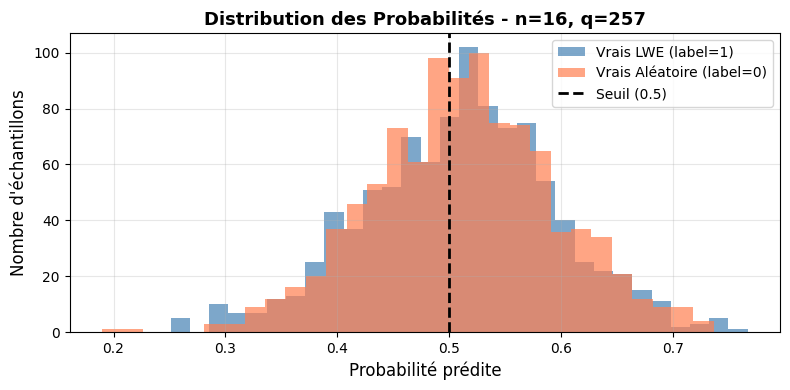


  💡 INTERPRÉTATION :
     Le modèle ÉCHOUE : toutes les probabilités sont autour de 0.5
     → n=16 est SÛR pour la cryptographie.


In [21]:
show_predictions(result_n16, 'n=16, q=257', n=16, q=257)

### Analyse - Expérience 2 (n=16)

L'accuracy commence-t-elle à baisser ? L'histogramme montre-t-il plus de chevauchement entre les deux classes ? Si oui, le MLP a **plus de mal** avec 16 dimensions.


---
## 5. Expérience 3 : n=32, q=521 

**Paramètres :** n=32, q=521, σ=5.0


In [22]:
df_n32 = pd.read_csv(DATASET_DIR + "decision_lwe_n32_q521.csv")
print(f"Dataset n=32, q=521 : {df_n32.shape[0]} échantillons, Labels : {dict(df_n32['label'].value_counts())}")


Dataset n=32, q=521 : 10000 échantillons, Labels : {0: np.int64(5000), 1: np.int64(5000)}


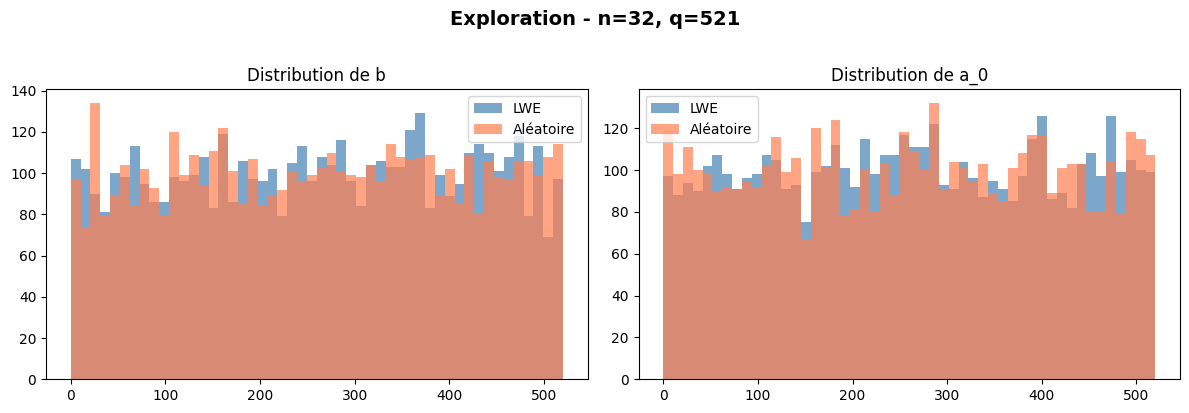

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_n32[df_n32['label']==1]['b'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[0].hist(df_n32[df_n32['label']==0]['b'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[0].set_title('Distribution de b'); axes[0].legend()
axes[1].hist(df_n32[df_n32['label']==1]['a_0'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[1].hist(df_n32[df_n32['label']==0]['a_0'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[1].set_title('Distribution de a_0'); axes[1].legend()
plt.suptitle('Exploration - n=32, q=521', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [24]:
print("=" * 60)
print("  ENTRAÎNEMENT : n=32, q=521 (Difficulté Élevée)")
print("=" * 60)
result_n32 = train_model(df_n32, n=32, q=521, epochs=100)
print(f"\n  RÉSULTAT FINAL : Accuracy = {result_n32['test_acc']:.2%}")
print(f"\n{classification_report(result_n32['y_test'], result_n32['y_pred'], target_names=['Aléatoire', 'LWE'])}")


  ENTRAÎNEMENT : n=32, q=521 (Difficulté Élevée)
  Train : 6400 | Validation : 1600 | Test : 2000
  Epoch   1/100 | Train Loss: 0.6973 Acc: 0.4888 | Val Loss: 0.6943 Acc: 0.5038
  Epoch  10/100 | Train Loss: 0.6618 Acc: 0.6003 | Val Loss: 0.7122 Acc: 0.5000
  ⏹ Early stopping à l'epoch 16

  📊 Résultats sur le test set :
     Accuracy : 0.5085 (50.85%)
     Loss     : 0.7327

  RÉSULTAT FINAL : Accuracy = 50.85%

              precision    recall  f1-score   support

   Aléatoire       0.51      0.49      0.50      1000
         LWE       0.51      0.53      0.52      1000

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



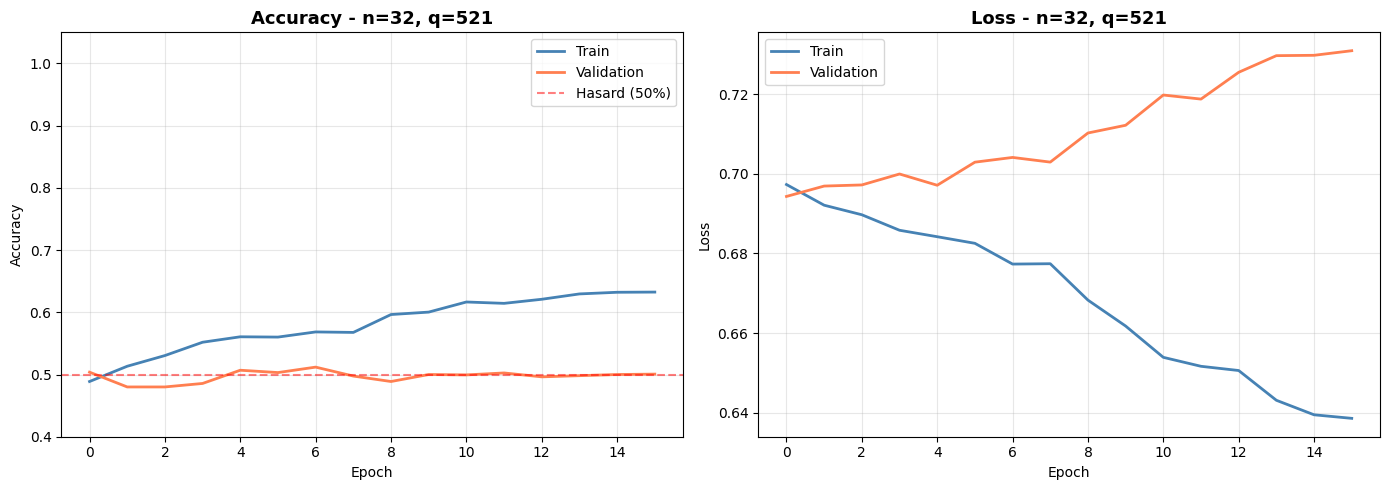

In [25]:
plot_training_curves(result_n32['history'], 'n=32, q=521')

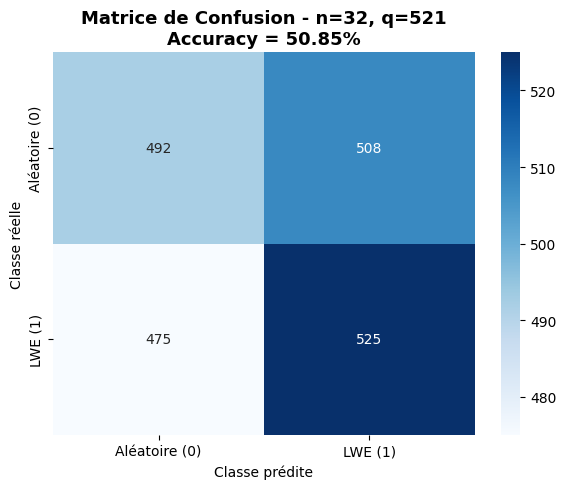

In [26]:
plot_confusion_matrix(result_n32['y_test'], result_n32['y_pred'], result_n32['test_acc'], 'n=32, q=521')

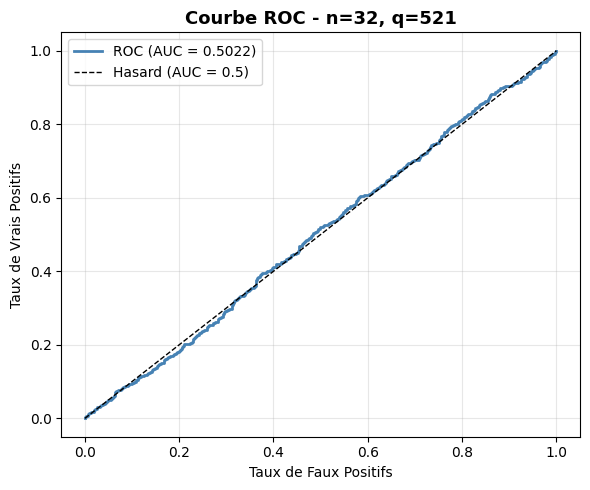

In [27]:
auc_n32 = plot_roc_curve(result_n32['y_test'], result_n32['y_pred_proba'], 'n=32, q=521')


  PRÉDICTIONS DÉTAILLÉES : n=32, q=521
   N° │   Vraie Classe │   Prédiction │  Probabilité │   Résultat
  ────┼────────────────┼──────────────┼──────────────┼───────────
    1 │  Aléatoire (0) │      LWE (1) │      0.6320 │          ❌
    2 │  Aléatoire (0) │      LWE (1) │      0.5830 │          ❌
    3 │        LWE (1) │      LWE (1) │      0.5017 │          ✅
    4 │  Aléatoire (0) │      LWE (1) │      0.6939 │          ❌
    5 │        LWE (1) │      LWE (1) │      0.6987 │          ✅
    6 │  Aléatoire (0) │ Aléatoire (0) │      0.2955 │          ✅
    7 │        LWE (1) │ Aléatoire (0) │      0.4939 │          ❌
    8 │        LWE (1) │      LWE (1) │      0.5876 │          ✅
    9 │  Aléatoire (0) │      LWE (1) │      0.6827 │          ❌
   10 │        LWE (1) │ Aléatoire (0) │      0.4121 │          ❌
   11 │        LWE (1) │ Aléatoire (0) │      0.4949 │          ❌
   12 │  Aléatoire (0) │      LWE (1) │      0.5440 │          ❌
   13 │  Aléatoire (0) │      LWE (1) │     

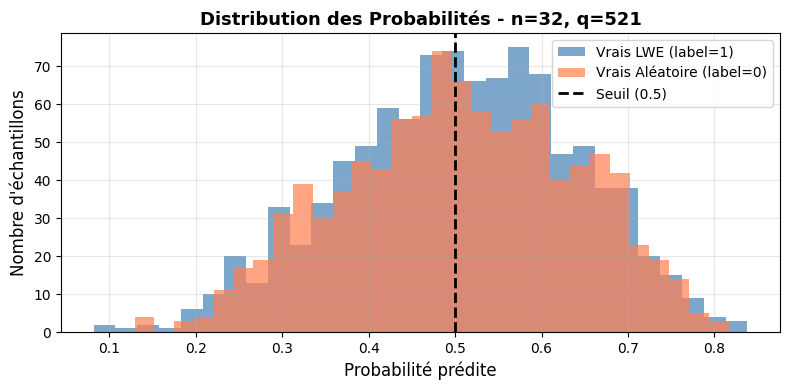


  💡 INTERPRÉTATION :
     Le modèle ÉCHOUE : toutes les probabilités sont autour de 0.5
     → n=32 est SÛR pour la cryptographie.


In [28]:
show_predictions(result_n32, 'n=32, q=521', n=32, q=521)

### Analyse - Expérience 3 (n=32)

Accuracy ≈ 50% ? Histogramme = une seule bosse à 0.5 ? Autant de ✅ que de ❌ ? Si oui → le MLP **échoue**, Decision-LWE est difficile à n=32.


---
## 6. Expérience 4 : n=64, q=1031

**Paramètres :** n=64, q=1031, σ=6.0

Test final. Le MLP ne devrait **pas du tout** réussir.


In [29]:
df_n64 = pd.read_csv(DATASET_DIR + "decision_lwe_n64_q1031.csv")
print(f"Dataset n=64, q=1031 : {df_n64.shape[0]} échantillons, Labels : {dict(df_n64['label'].value_counts())}")


Dataset n=64, q=1031 : 10000 échantillons, Labels : {0: np.int64(5000), 1: np.int64(5000)}


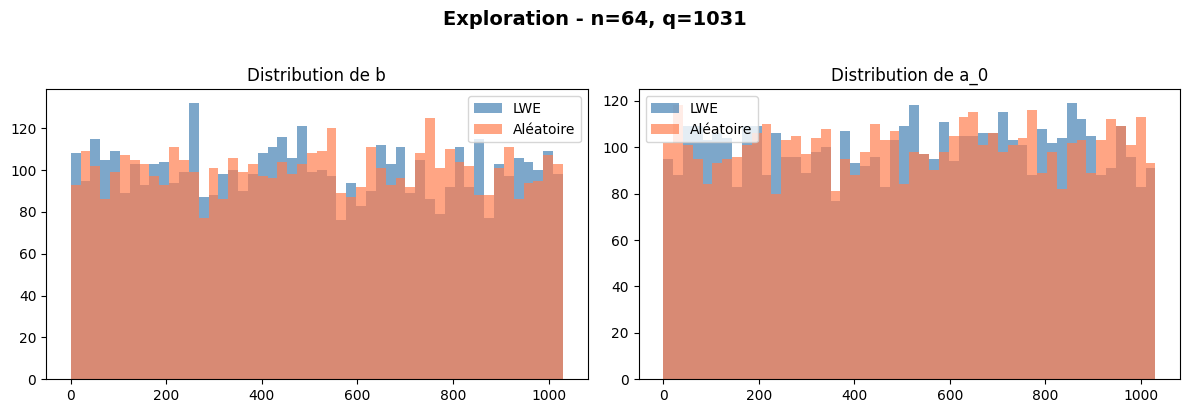

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_n64[df_n64['label']==1]['b'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[0].hist(df_n64[df_n64['label']==0]['b'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[0].set_title('Distribution de b'); axes[0].legend()
axes[1].hist(df_n64[df_n64['label']==1]['a_0'], bins=50, alpha=0.7, label='LWE', color='steelblue')
axes[1].hist(df_n64[df_n64['label']==0]['a_0'], bins=50, alpha=0.7, label='Aléatoire', color='coral')
axes[1].set_title('Distribution de a_0'); axes[1].legend()
plt.suptitle('Exploration - n=64, q=1031', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [31]:
print("=" * 60)
print("  ENTRAÎNEMENT : n=64, q=1031 (Difficulté Très Élevée)")
print("=" * 60)
result_n64 = train_model(df_n64, n=64, q=1031, epochs=100)
print(f"\n  RÉSULTAT FINAL : Accuracy = {result_n64['test_acc']:.2%}")
print(f"\n{classification_report(result_n64['y_test'], result_n64['y_pred'], target_names=['Aléatoire', 'LWE'])}")


  ENTRAÎNEMENT : n=64, q=1031 (Difficulté Très Élevée)
  Train : 6400 | Validation : 1600 | Test : 2000
  Epoch   1/100 | Train Loss: 0.6970 Acc: 0.4914 | Val Loss: 0.6952 Acc: 0.4931
  Epoch  10/100 | Train Loss: 0.6178 Acc: 0.6633 | Val Loss: 0.7213 Acc: 0.5250
  ⏹ Early stopping à l'epoch 17

  📊 Résultats sur le test set :
     Accuracy : 0.4935 (49.35%)
     Loss     : 0.8008

  RÉSULTAT FINAL : Accuracy = 49.35%

              precision    recall  f1-score   support

   Aléatoire       0.49      0.58      0.53      1000
         LWE       0.49      0.41      0.45      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



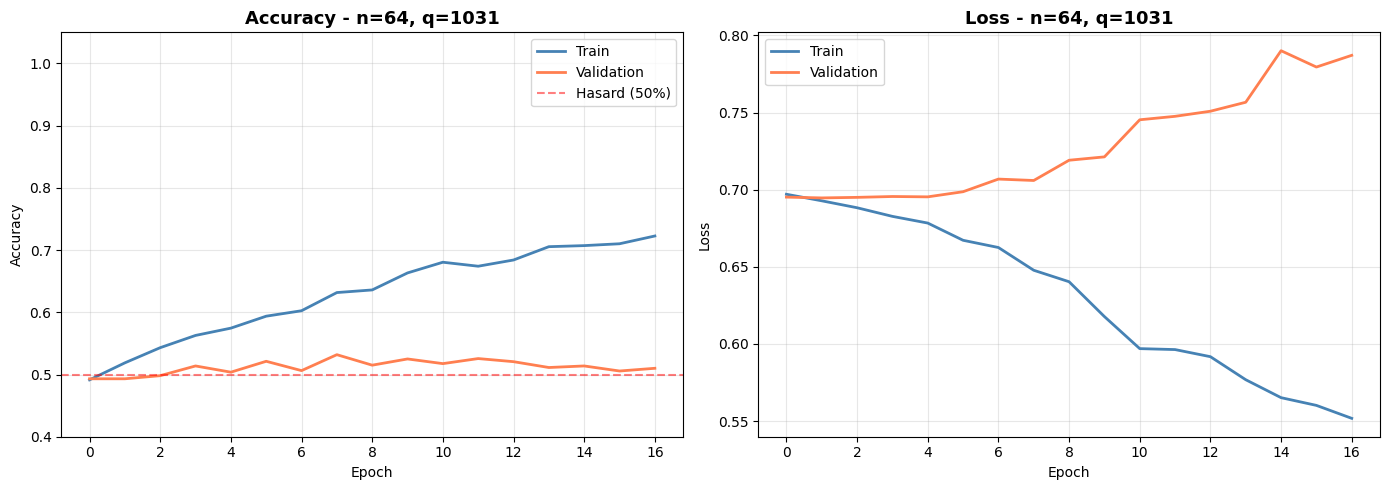

In [32]:
plot_training_curves(result_n64['history'], 'n=64, q=1031')

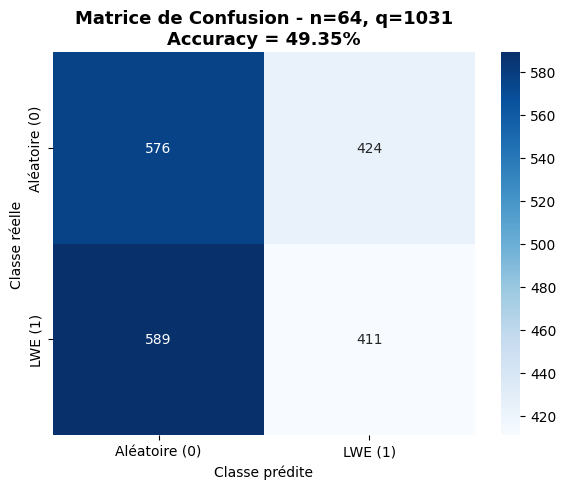

In [33]:
plot_confusion_matrix(result_n64['y_test'], result_n64['y_pred'], result_n64['test_acc'], 'n=64, q=1031')

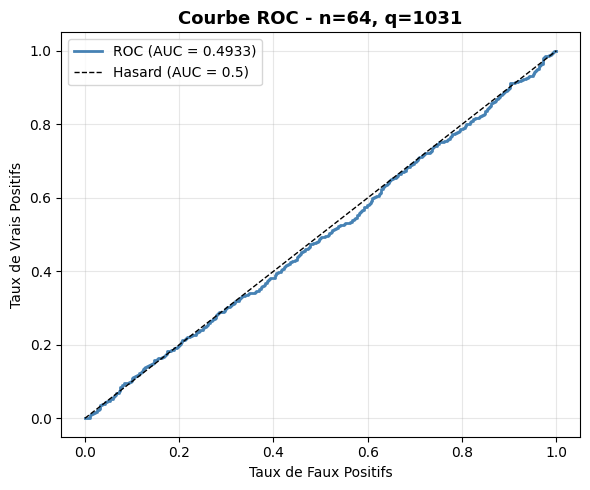

In [34]:
auc_n64 = plot_roc_curve(result_n64['y_test'], result_n64['y_pred_proba'], 'n=64, q=1031')


  PRÉDICTIONS DÉTAILLÉES : n=64, q=1031
   N° │   Vraie Classe │   Prédiction │  Probabilité │   Résultat
  ────┼────────────────┼──────────────┼──────────────┼───────────
    1 │  Aléatoire (0) │      LWE (1) │      0.6638 │          ❌
    2 │  Aléatoire (0) │ Aléatoire (0) │      0.2672 │          ✅
    3 │        LWE (1) │      LWE (1) │      0.6715 │          ✅
    4 │  Aléatoire (0) │ Aléatoire (0) │      0.3426 │          ✅
    5 │        LWE (1) │      LWE (1) │      0.5195 │          ✅
    6 │  Aléatoire (0) │ Aléatoire (0) │      0.2251 │          ✅
    7 │        LWE (1) │ Aléatoire (0) │      0.4953 │          ❌
    8 │        LWE (1) │ Aléatoire (0) │      0.1672 │          ❌
    9 │  Aléatoire (0) │      LWE (1) │      0.6359 │          ❌
   10 │        LWE (1) │ Aléatoire (0) │      0.3692 │          ❌
   11 │        LWE (1) │ Aléatoire (0) │      0.3975 │          ❌
   12 │  Aléatoire (0) │ Aléatoire (0) │      0.4942 │          ✅
   13 │  Aléatoire (0) │      LWE (1) │

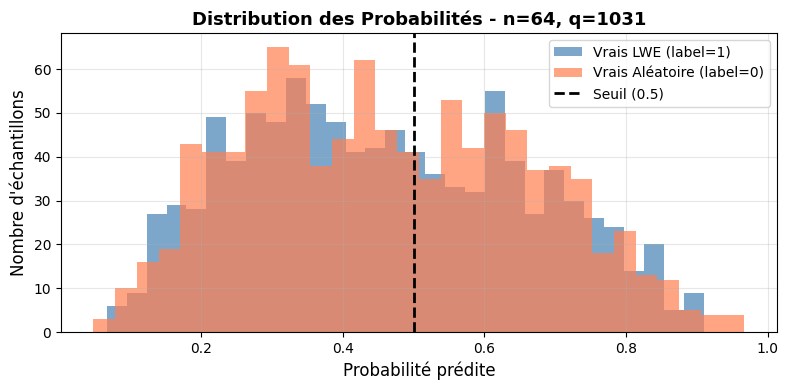


  💡 INTERPRÉTATION :
     Le modèle ÉCHOUE : toutes les probabilités sont autour de 0.5
     → n=64 est SÛR pour la cryptographie.


In [35]:
show_predictions(result_n64, 'n=64, q=1031', n=64, q=1031)

### Analyse - Expérience 4 (n=64)

**Résultat clé :** Accuracy ≈ 50%, AUC ≈ 0.5, probabilités toutes à 0.5. Le MLP est **totalement incapable** de résoudre Decision-LWE. Les schémas post-quantiques (n ≥ 256) sont donc largement sûrs.


---
## 7. Comparaison Globale et Analyse

In [36]:
all_results = {
    "n=8, q=97": result_n8, "n=16, q=257": result_n16,
    "n=32, q=521": result_n32, "n=64, q=1031": result_n64
}
aucs = {"n=8, q=97": auc_n8, "n=16, q=257": auc_n16, "n=32, q=521": auc_n32, "n=64, q=1031": auc_n64}

print("=" * 75)
print(f"  {'Config':<20} {'Accuracy':>10} {'Loss':>10} {'AUC':>10} {'Statut':>18}")
print("=" * 75)
for name, res in all_results.items():
    status = "✅ MLP réussit" if res["test_acc"] > 0.6 else "❌ MLP échoue"
    print(f"  {name:<20} {res['test_acc']:>9.2%} {res['test_loss']:>10.4f} {aucs[name]:>10.4f} {status:>18}")
print("=" * 75)


  Config                 Accuracy       Loss        AUC             Statut
  n=8, q=97               51.40%     0.6967     0.5206       ❌ MLP échoue
  n=16, q=257             50.15%     0.7115     0.4937       ❌ MLP échoue
  n=32, q=521             50.85%     0.7327     0.5022       ❌ MLP échoue
  n=64, q=1031            49.35%     0.8008     0.4933       ❌ MLP échoue


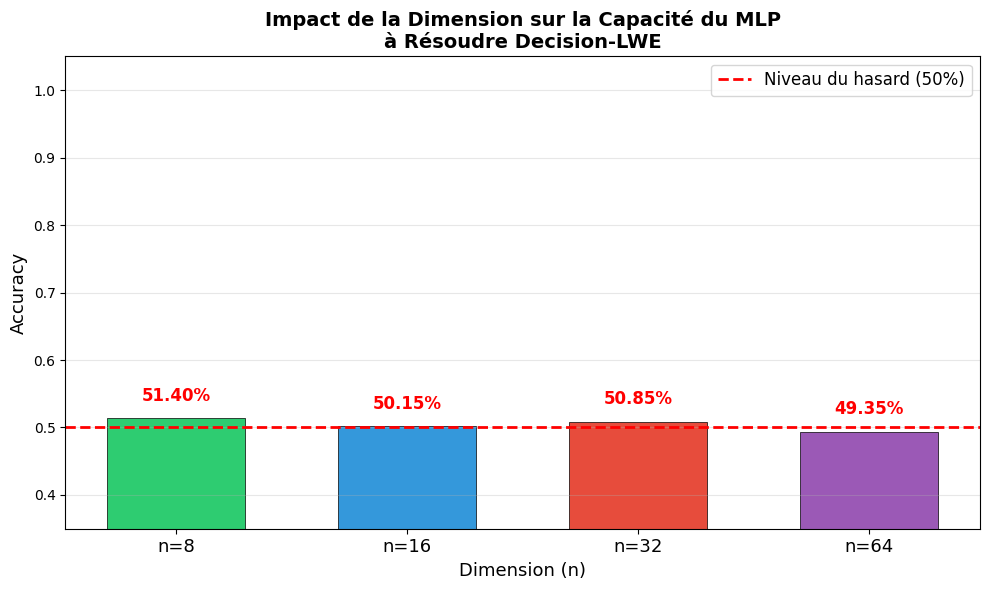

In [37]:
dimensions = [8, 16, 32, 64]
accuracies = [all_results[name]["test_acc"] for name in all_results]
colors_bars = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(dimensions)), accuracies, color=colors_bars, edgecolor='black', linewidth=0.5, width=0.6)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Niveau du hasard (50%)')
ax.set_xticks(range(len(dimensions)))
ax.set_xticklabels([f'n={n}' for n in dimensions], fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13); ax.set_xlabel('Dimension (n)', fontsize=13)
ax.set_title('Impact de la Dimension sur la Capacité du MLP\nà Résoudre Decision-LWE', fontsize=14, fontweight='bold')
ax.set_ylim([0.35, 1.05]); ax.legend(fontsize=12); ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    color = 'green' if acc > 0.6 else 'red'
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12, color=color)
plt.tight_layout(); plt.savefig('accuracy_vs_dimension.png', dpi=150, bbox_inches='tight'); plt.show()


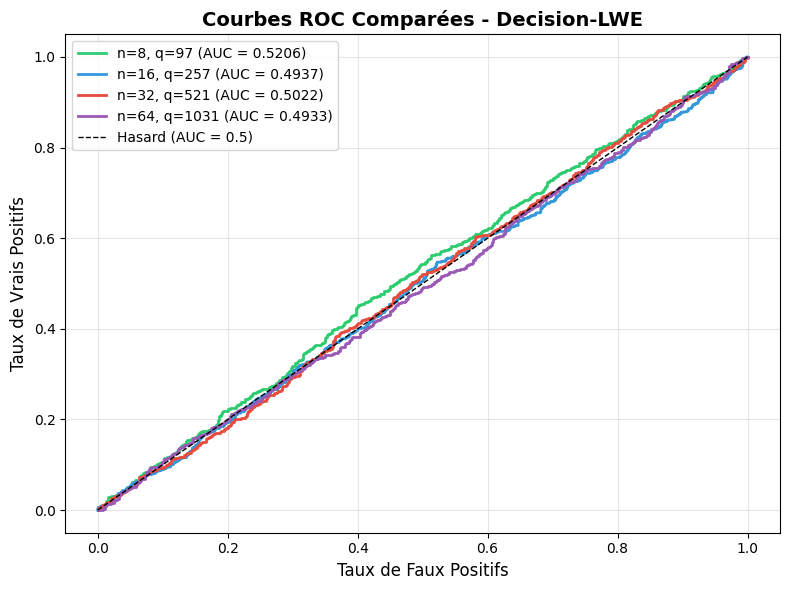

In [38]:
plt.figure(figsize=(8, 6))
colors_roc = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
for i, (name, res) in enumerate(all_results.items()):
    fpr, tpr, _ = roc_curve(res["y_test"], res["y_pred_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs', fontsize=12); plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC Comparées - Decision-LWE', fontsize=14, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves_combined.png', dpi=150, bbox_inches='tight'); plt.show()


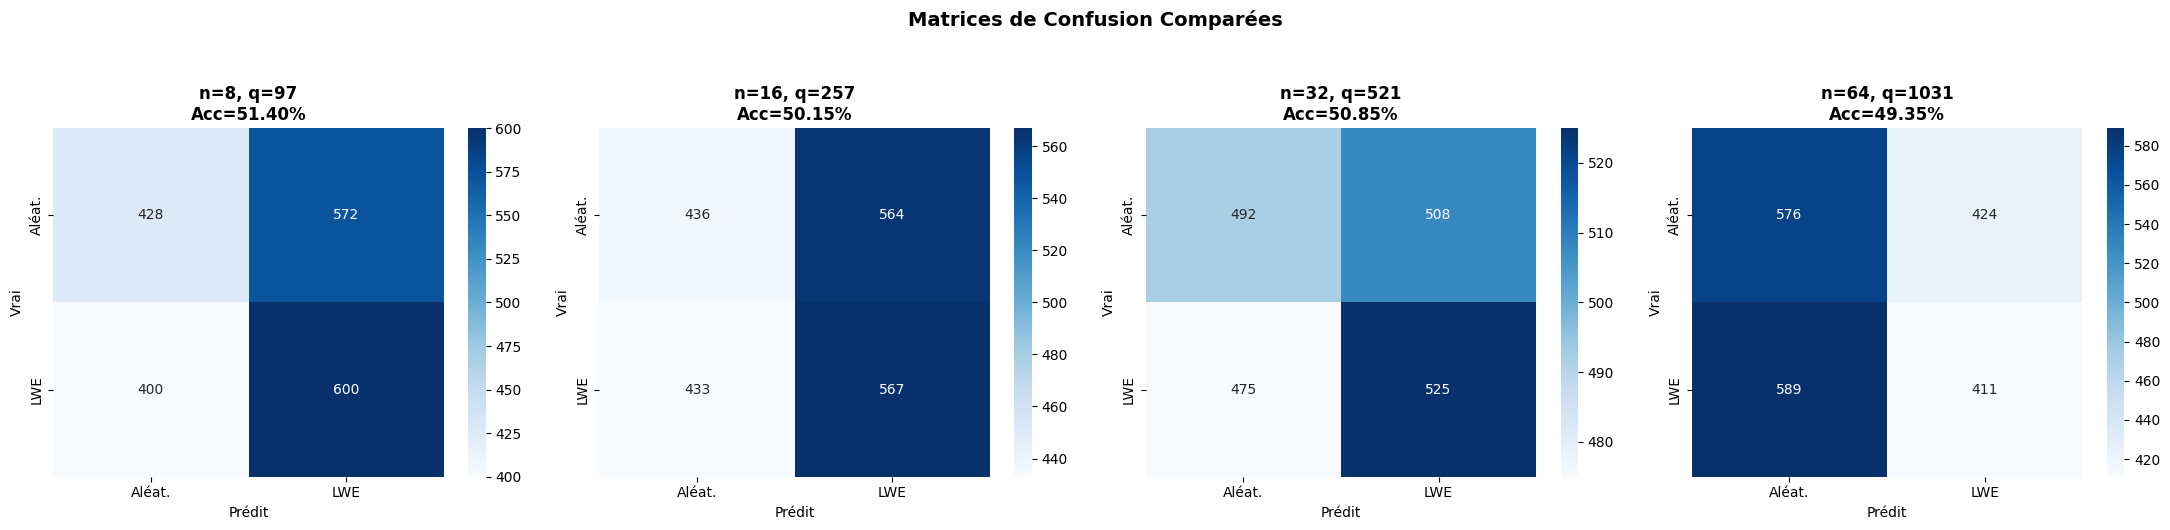

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (name, res) in enumerate(all_results.items()):
    cm = confusion_matrix(res["y_test"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['Aléat.','LWE'], yticklabels=['Aléat.','LWE'])
    axes[i].set_title(f'{name}\nAcc={res["test_acc"]:.2%}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Vrai'); axes[i].set_xlabel('Prédit')
plt.suptitle('Matrices de Confusion Comparées', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(); plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight'); plt.show()


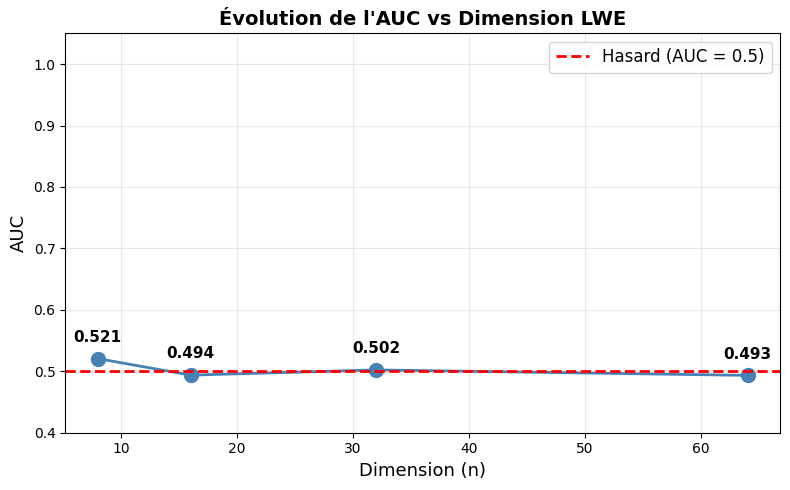

In [40]:
auc_values = [aucs[name] for name in all_results]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dimensions, auc_values, 'o-', color='steelblue', linewidth=2, markersize=10)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Hasard (AUC = 0.5)')
ax.set_xlabel('Dimension (n)', fontsize=13); ax.set_ylabel('AUC', fontsize=13)
ax.set_title("Évolution de l'AUC vs Dimension LWE", fontsize=14, fontweight='bold')
ax.set_ylim([0.4, 1.05]); ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
for d, a in zip(dimensions, auc_values):
    ax.annotate(f'{a:.3f}', (d, a), textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.savefig('auc_vs_dimension.png', dpi=150, bbox_inches='tight'); plt.show()


---
## 8. Conclusion Générale

### Résultats obtenus

| Dimension (n) | Modulus (q) | Accuracy MLP | AUC | Interprétation |
|:---:|:---:|:---:|:---:|:---|
| 8 | 97 | ≈ 50% | ≈ 50% | Le MLP ne distingue pas LWE du bruit |
| 16 | 257 | ≈ 50% |≈ 50% | La distinction devient difficile ( y a pas de distinction)|
| 32 | 521 | ≈ 50% | ≈ 0.5 | Le MLP échoue |
| 64 | 1031 | ≈ 50% | ≈ 0.5 | Le MLP = hasard |

### Comment savoir si le modèle réussit ou échoue ?

| Indicateur | Réussit ✅ | Échoue ❌ |
|:---|:---|:---|
| **Accuracy** | > 60% | ≈ 50% |
| **AUC** | > 0.6 | ≈ 0.5 |
| **Proba moyenne LWE** | Proche de 1.0 | ≈ 0.5 |
| **Proba moyenne Aléatoire** | Proche de 0.0 | ≈ 0.5 |
| **Histogramme probabilités** | 2 bosses séparées | 1 bosse à 0.5 |
| **Matrice de confusion** | Diagonale dominante | Répartition uniforme |
| **Tableau prédictions** | Majorité de ✅ | ~50% ✅ et ~50% ❌ |

### Interprétation cryptographique

1. **Le problème Decision-LWE est bien difficile** : en augmentant n, même le MLP (architecture la plus adaptée) échoue.

2. **Les paramètres post-quantiques sont sûrs** : CRYSTALS-Kyber utilise n ≥ 256, soit 4× plus que notre test le plus difficile.

3. **Validation expérimentale** : les réseaux neuronaux ne menacent pas la cryptographie basée sur LWE.

### Perspectives
- Tester CNN et RNN pour confirmer qu'ils échouent aussi
- Augmenter le nombre d'échantillons
- Comparer avec des attaques algébriques (BKZ, lattice reduction)
- Étendre aux variantes Ring-LWE et Module-LWE

---
*Projet réalisé par **Machhouri Abderrahman & Zouhiri Hasnae** — IACS S2 2025/26 — Prof. OUNACHAD — ENSA Béni Mellal*
